In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Calling basic_cleaning_and_split from the preprocessing notebook to get the data
from preprocessing import  df_basic_cleaning_and_split, array_standardise_data, df_feature_constructions

np.random.seed(42)

## Train/Test Split

In [30]:
include_added_features = False
if include_added_features:  
    X_train, X_test, y_train, y_test = df_basic_cleaning_and_split(test_size=0.3)
    X_train, X_test = df_feature_constructions(X_train, X_test)
    X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)
else:
    X_train, X_test, y_train, y_test = df_basic_cleaning_and_split(test_size=0.3, include_additional_features=False)
    X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)
    
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(14448, 8)
(14448, 1)
(6192, 8)
(6192, 1)


## Helper Functions

Sigmoid was used in the workshop, however this was a binary classification problem. Here we are trying to predict house prices and so our output doesnt want to be in the range (0,1). So we use ReLu instead, which is another common activation function. It is defined as f(z) = max(0, z). 

In [31]:
# Activation function
def relu(z):
    return np.maximum(0, z)

# Derivative of the activation function (relu)
def drelu(a):
    return (a > 0).astype(float)

# Root mean squared error loss function
# We times by 0.5 to make the mse derivative simpler.
#  
def mse_loss(y_pred, y_true, n):
    # Root mean squared error (scalar)
    return np.mean((y_pred - y_true)**2)

# Used for setting the random seed for reproducibility
def set_seed(seed=0):
    np.random.seed(seed)

def plot_loss_curve(losses, title="Loss curve"):
    plt.figure(figsize=(6,4))
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title(title)
    plt.show()


## Forward Propagation

Using 1 hidden layers of k neurons (variable -> num_hidden_neurons) (choice was arbitrary), and an output layer of 1 neuron (median price prediction).

In [32]:
num_hidden_neurons = 64

In [33]:
# Example of the weights and biases. Used for checking first iteration is working correctly.

# Capitals implies that its a matrix (), lowercase is a vector.
W1 = 0.5*np.random.rand(X_train.shape[1], num_hidden_neurons)
# Note, in the worksheet, times by 0.5. Maybe change later?
b1 = np.zeros(num_hidden_neurons)

w2 = 0.5*np.random.rand(num_hidden_neurons, 1) # (5, 1) for w2
b2 = np.zeros(1)

In [34]:
w2.shape

(64, 1)

In [35]:
def forward(X, W1, b1, w2, b2):
    z1 = X @ W1 + b1
    # Applying activation function (relu) to the hidden layer
    a1 = relu(z1)

    z2 = a1 @ w2 + b2
    y_hat = z2 # Explain why not applying activation function to the output layer (regression problem)
    # Cache is used to store temporary values
    cache = {"z1": z1, "a1": a1, "z2": z2, "y_hat": y_hat}  
    return y_hat, cache

y_hat, cache = forward(X_train, W1, b1, w2, b2)
loss = mse_loss(y_hat, y_train, n=X_train.shape[0])

print("Predictions (y_hat):\n", np.round(y_hat, 3))
print("Loss:", loss)

Predictions (y_hat):
 [[1.622]
 [0.035]
 [0.   ]
 ...
 [0.813]
 [2.923]
 [6.939]]
Loss: 105.61320690337396


The central difference approximation to the partial derivative with respect to $x$ is (Assuming a 2 variable function):

$$
\frac{\partial f}{\partial x}(x, y)
\approx
\frac{f(x + \varepsilon, y) - f(x - \varepsilon, y)}{2\varepsilon}
$$

In [36]:
# This code is for checking that the derivative with respect to w2 is correct.

def loss_with_params(X, y, W1, b1, w2, b2):
    # "_" to ignore the cache
    y_hat, _ = forward(X, W1, b1, w2, b2)
    # Calculating the loss for the given parameters 
    return mse_loss(y_hat, y, n=X.shape[0])

# Computes an approximation of the partial derivative of the loss with respect to w2.
# This is done by using the central difference formula.
def numerical_grad_w2(X, y, W1, b1, w2, b2, eps=1e-5):
    # Return an array of zeros with the same shape as w2, used to store the numerical gradients
    grad = np.zeros_like(w2)

    # Iterating over each row of w2
    for i in range(w2.shape[0]):
        # Iterating over each column of w2
        for j in range(w2.shape[1]):

            # w2_pos and w2_neg are copies of w2 where we will add and subtract eps to the (i, j) 
            # element respectively
            w2_pos = w2.copy(); w2_neg = w2.copy()
            w2_pos[i, j] += eps
            w2_neg[i, j] -= eps

            # The result from a small step in the positive and negative w2 direction.
            # i.e the f(x + eps, y) and f(x - eps, y) notated above.
            L_pos = loss_with_params(X, y, W1, b1, w2_pos, b2)
            L_neg = loss_with_params(X, y, W1, b1, w2_neg, b2)

            # Approximated gradient for that element of w2
            grad[i, j] = (L_pos - L_neg) / (2*eps)
        # This is repeated for each w2 element.
    return grad

num_gw2 = numerical_grad_w2(X_train, y_train, W1, b1, w2, b2, eps=1e-5)
print("Numerical gradient dL/dw2:\n", np.round(num_gw2, 6)[:5])

Numerical gradient dL/dw2:
 [[12.52311 ]
 [15.526283]
 [11.3869  ]
 [ 6.835663]
 [13.13601 ]]


In [37]:
# Actual backpropagation
def backprop(X, y, W1, b1, w2, b2):
    N = X.shape[0] # No. of rows (number of samples)
    y_hat, cache = forward(X, W1, b1, w2, b2)
    a1 = cache["a1"] # Hidden layer 

    dL_dyhat = 2 * (y_hat - y) / N
    dL_dz2 = dL_dyhat  # ReLu not used on output (CHECK correct)

    dw2 = a1.T @ dL_dz2
    db2 = np.sum(dL_dz2, axis=0)

    dL_da1 = dL_dz2 @ w2.T
    dL_dz1 = dL_da1 * drelu(a1)

    dW1 = X.T @ dL_dz1
    db1 = np.sum(dL_dz1, axis=0)

    return {"dW1": dW1, "db1": db1, "dw2": dw2, "db2": db2}

grads = backprop(X_train, y_train, W1, b1, w2, b2)
print("Backprop gradient dL/dw2:\n", np.round(grads["dw2"], 6)[:5])

Backprop gradient dL/dw2:
 [[12.52311 ]
 [15.526283]
 [11.3869  ]
 [ 6.835663]
 [13.13601 ]]


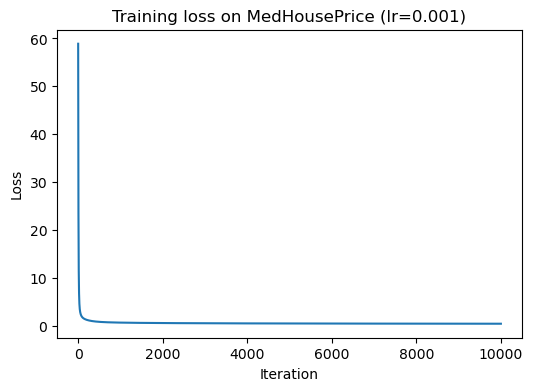

Final loss: 0.4594242589771492


In [38]:
def train_NN(X, y, hidden=num_hidden_neurons, lr=1.0, iters=4000, seed=2):
    set_seed(seed)
    W1 = 0.5*np.random.randn(X.shape[1], hidden)
    b1 = np.zeros(hidden)
    w2 = 0.5*np.random.randn(hidden, 1)
    b2 = np.zeros(1)

    losses = []
    for t in range(iters):
        y_hat, _ = forward(X, W1, b1, w2, b2)
        L = mse_loss(y_hat, y, n=X.shape[0])
        losses.append(L)

        grads = backprop(X, y, W1, b1, w2, b2)
        W1 -= lr * grads["dW1"]
        b1 -= lr * grads["db1"]
        w2 -= lr * grads["dw2"]
        b2 -= lr * grads["db2"]

    return W1, b1, w2, b2, losses

lr = 0.001 # Learning rate
iters = 10000

W1_t, b1_t, w2_t, b2_t, losses = train_NN(X_train, y_train, hidden=num_hidden_neurons, lr=lr, iters=iters, seed=2)
plot_loss_curve(losses, title=f"Training loss on MedHousePrice (lr={lr})")
# print(losses)
y_hat, _ = forward(X_train, W1_t, b1_t, w2_t, b2_t)
# print("Final predictions:", np.round(y_hat.T, 3))
print("Final loss:", losses[-1])

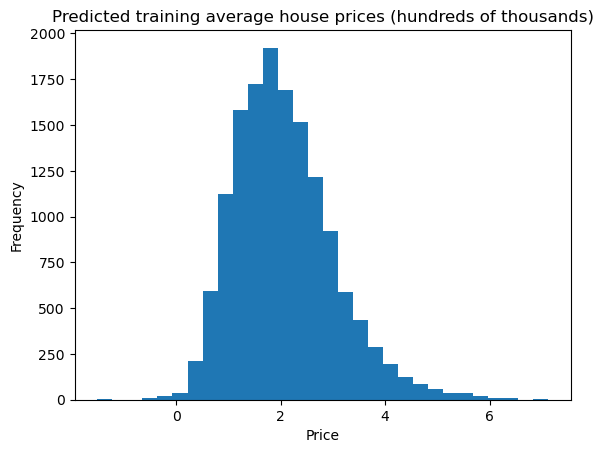

In [39]:
plt.hist(y_hat, bins=30)
plt.title("Predicted training average house prices (hundreds of thousands)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [40]:
print(y_hat[:5])
print(y_train[:5])

[[1.95923582]
 [1.91907011]
 [2.98198339]
 [0.89980736]
 [2.46542936]]
[[1.938  ]
 [1.697  ]
 [2.598  ]
 [1.361  ]
 [5.00001]]


## Testing the model

The parameters of the model are W1_t, b1_t, W2_t, b2_t. We can use these to make predictions on the test set and evaluate the performance of the model.

In [41]:
def predict(X, W1, b1, w2, b2):
    y_hat, _ = forward(X, W1, b1, w2, b2)
    return y_hat

y_pred_test = predict(X_test, W1_t, b1_t, w2_t, b2_t)

test_loss = mse_loss(y_pred_test, y_test, n=X_test.shape[0])
print("Test loss:", test_loss)

print(y_test[:5])
print(y_pred_test[:5])

Test loss: 0.45936635095032574
[[0.477  ]
 [0.458  ]
 [5.00001]
 [2.186  ]
 [2.78   ]]
[[0.7925557 ]
 [1.65457096]
 [2.93735686]
 [2.85650747]
 [2.38681037]]
